  Time |   Body 1 X |   Body 1 Y
--------------------------------
  0.00 |    -0.9700 |     0.2431
  1.27 |     0.2027 |    -0.1767
  2.53 |     1.0772 |    -0.0481
  3.80 |     0.4198 |     0.3070
  5.07 |    -0.8462 |    -0.3218


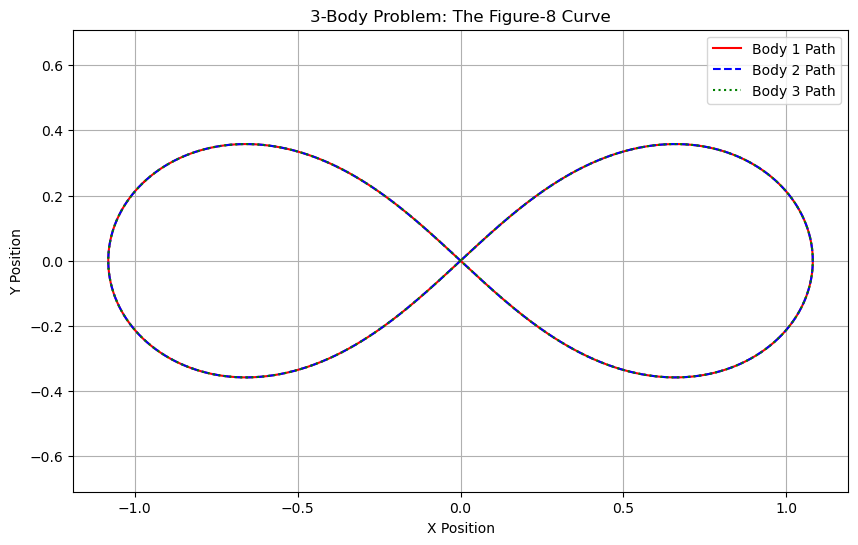

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def simulate_figure_eight():
    # Physical Constants
    G = 1.0
    masses = [1.0, 1.0, 1.0]

    # Initial Conditions for the stable Figure-8 orbit
    # Positions (x, y) for 3 bodies
    x1, y1 = -0.97000436, 0.24308753
    x2, y2 = 0.97000436, -0.24308753
    x3, y3 = 0.0, 0.0
    
    # Velocities (vx, vy) 
    # v3 is the primary velocity, others are set to keep net momentum at zero
    vx3, vy3 = -0.93240737, -0.86473146
    vx1, vy1 = -0.5 * vx3, -0.5 * vy3
    vx2, vy2 = -0.5 * vx3, -0.5 * vy3

    # The differential equation function (F = ma)
    def n_body_equations(t, state):
        pos = state[:6].reshape((3, 2))
        vel = state[6:].reshape((3, 2))
        acc = np.zeros((3, 2))
        
        for i in range(3):
            for j in range(3):
                if i != j:
                    r_vec = pos[j] - pos[i]
                    r_mag = np.linalg.norm(r_vec)
                    acc[i] += G * masses[j] * r_vec / r_mag**3
        
        return np.concatenate([vel.flatten(), acc.flatten()])

    # Combine initial positions and velocities into one state vector
    initial_state = [x1, y1, x2, y2, x3, y3, vx1, vy1, vx2, vy2, vx3, vy3]
    
    # Solve for one full period (approx 6.32 seconds)
    t_span = (0, 6.3259)
    t_eval = np.linspace(t_span[0], t_span[1], 1000)

    solution = solve_ivp(n_body_equations, t_span, initial_state, 
                         t_eval=t_eval, rtol=1e-10)
    return solution

# 1. Run the simulation
sol = simulate_figure_eight()

# 2. Print a sample of the raw curve data (X, Y points)
print(f"{'Time':>6} | {'Body 1 X':>10} | {'Body 1 Y':>10}")
print("-" * 32)
for i in range(0, 1000, 200):
    print(f"{sol.t[i]:6.2f} | {sol.y[0][i]:10.4f} | {sol.y[1][i]:10.4f}")

# 3. Visualize and save the curve
plt.figure(figsize=(10, 6))
plt.plot(sol.y[0], sol.y[1], 'r-', label='Body 1 Path')
plt.plot(sol.y[2], sol.y[3], 'b--', label='Body 2 Path')
plt.plot(sol.y[4], sol.y[5], 'g:', label='Body 3 Path')
plt.title("3-Body Problem: The Figure-8 Curve")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()